# 🧠 3D Trajectory Prediction: Neural ODE Showcase (Tutorial Baseline)

이 노트북은 **"딥러닝과 물리 역학 수치 적분(ODE)을 어떻게 결합할 수 있는가?"**를 설명하기 위해 제작된 교육 및 공유용 **Neural ODE 쇼케이스 베이스라인**입니다.

실제 대회 솔루션에서 쓰이는 무거운 특징 가공이나 복잡한 감쇄항을 모두 배제하고, 오직 **위치와 속도로 이루어진 6차원 상태계** 위에 가속도 필드를 뉴럴 네트워크로 설계하여 수치 적분하는 과정을 가장 직관적이고 단순한 코드로 소개합니다.

### 💡 Neural ODE의 핵심 컨셉
- 기존 시계열 모델은 과거 시퀀스를 받아 미래 위치 $y$를 직접 회귀(Regression)합니다. 
- 반면 **Neural ODE**는 모기의 비행을 연속적인 시간 흐름상의 미분 방정식으로 정의합니다:
  $$\frac{d\vec{x}}{dt} = \vec{v}(t)$$
  $$\frac{d\vec{v}}{dt} = \vec{a}_{neural}(\vec{x}(t), \vec{v}(t))$$
- 여기서 가속도 함수 $\vec{a}_{neural}$을 신경망(MLP)으로 모형화하고, 이를 **오일러(Euler) 수치 적분**을 통해 순방향 전파하면서 최종 예측을 도출합니다.

---

## 1. 라이브러리 및 연산 장치 설정

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from tqdm import tqdm

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"연산 장치: {device}")

연산 장치: mps


## 2. 데이터 처리 및 정규화 (Simple Dataset)
데이터 로드 및 11개 관측 좌표로부터 로컬 좌표계 정렬과 기본적인 11-step 데이터셋을 빌드합니다.

In [2]:
cache_dir = "data/cache"
train_coords_path = os.path.join(cache_dir, "train_coords.npy")
train_targets_path = os.path.join(cache_dir, "train_targets.npy")
test_coords_path = os.path.join(cache_dir, "test_coords.npy")
if os.path.exists(train_coords_path) and os.path.exists(train_targets_path):
    X_train = np.load(train_coords_path)
    y_train = np.load(train_targets_path)
else:
    print("⚠️ 캐시 파일을 찾을 수 없어 학습용 임시 더미 데이터를 생성합니다.")
    X_train = np.random.randn(100, 11, 3).astype(np.float32) * 0.1
    y_train = X_train[:, 10, :] + np.random.randn(100, 3).astype(np.float32) * 0.02
if os.path.exists(test_coords_path):
    X_test = np.load(test_coords_path)
else:
    X_test = np.random.randn(30, 11, 3).astype(np.float32) * 0.1

class MosquitoSimpleDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## 3. 로컬 좌표계 정렬 및 24차원 스케일드 피처 변환
방향 각도에 독립적으로 비행 동역학을 학습하기 위해, 로컬 좌표계를 구축하고 속도, 가속도, Jerk(가속도의 변화량), 헤딩 각도($\theta$) 및 이동 표준편차 등 24차원의 강력한 피처를 추출합니다. 피처들 간의 단위 스케일 차이를 맞춰 학습을 극도로 빠르고 안정적으로 만들기 위해, 훈련 데이터의 평균과 표준편차를 이용해 정규화(Scaling)를 수행합니다.

In [4]:
from model.utils import extract_features
print("✅ 24차원 스케일드 피처 추출기(extract_features) 로드 완료!")

## 4. 물리 기반 Neural ODE 모델 아키텍처 설계
이 단계에서는 물리학적 정규화 및 적분기(Solver)를 반영하여 한층 더 강력해진 Neural ODE 아키텍처를 설계합니다.

### 🌟 반영된 물리 기반 메커니즘
1. **학습 가능한 물리 댐핑 (Learned Physics-informed Damping)**: 모기가 공기 저항(마찰)을 받는 물리적 환경을 모사하여 속도에 비례하는 저항항($-\text{damping} \times \vec{v}$)을 도입합니다. 감쇄 계수는 학습 가능한 파라미터(`nn.Parameter`)로 정의되어 역전파를 통해 최적화됩니다.
2. **4차 런게-쿠타(RK4) 수치 적분기**: 단순한 1차 오일러 적분 대신 시뮬레이션의 누적 오차를 극적으로 감소시키고 궤적의 안정성을 보장하기 위해 고성능 **Runge-Kutta 4th Order** 기법을 탑재합니다.
3. **로컬/글로벌 바이어스 보정**: 물리 공간 정렬 오차 및 잔차 모션을 학습 가능한 오프셋 바이어스로 보정합니다.

In [5]:
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(dim, dim)
        )
        self.ln = nn.LayerNorm(dim)
    def forward(self, x):
        return self.ln(x + self.net(x))

class SimpleAccelerationField(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        # 입력: 현재 위치(3) + 현재 속도(3) + 컨텍스트 벡터(latent_dim) + Yaw 각도(1) + 기준 속력(1) = 8 + latent_dim
        self.net = nn.Sequential(
            nn.Linear(3 + 3 + latent_dim + 2, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            ResBlock(64),
            nn.Linear(64, 3)
        )
    def forward(self, pos, vel, latent, theta, speed):
        if theta.dim() == 1:
            theta = theta.unsqueeze(-1)
        if speed.dim() == 1:
            speed = speed.unsqueeze(-1)
        inputs = torch.cat([pos, vel, latent, theta, speed], dim=-1)
        return self.net(inputs)

class SimpleNeuralODEModel(nn.Module):
    def __init__(self, input_dim=24, latent_dim=64):
        super().__init__()
        # 과거 궤적 특징을 미분 컨텍스트 벡터로 인코딩하는 백본
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.GELU(),
            ResBlock(latent_dim)
        )
        self.accel_field = SimpleAccelerationField(latent_dim=latent_dim)
        
        # 물리 기반 학습 파라미터
        self.learned_damping = nn.Parameter(torch.tensor([0.1, 0.1, 0.1]))
        self.local_bias = nn.Parameter(torch.zeros(3))
        self.global_bias = nn.Parameter(torch.zeros(3))
        
        self.dt_physical = 0.08  # ode_v1 기준: 80ms 단일 적분
        self._last_accels = []

    def _ode_derivative(self, pos, vel, latent, theta, speed):
        accel = self.accel_field(pos, vel, latent, theta, speed)
        dpos = vel
        dvel = -self.learned_damping * vel + accel
        return dpos, dvel, accel

    def _rk4_single_step(self, init_pos, init_vel, latent, theta, speed):
        dt = self.dt_physical
        
        dp1, dv1, a1 = self._ode_derivative(init_pos, init_vel, latent, theta, speed)
        pos_k2 = init_pos + 0.5 * dt * dp1
        vel_k2 = init_vel + 0.5 * dt * dv1
        
        dp2, dv2, a2 = self._ode_derivative(pos_k2, vel_k2, latent, theta, speed)
        pos_k3 = init_pos + 0.5 * dt * dp2
        vel_k3 = init_vel + 0.5 * dt * dv2
        
        dp3, dv3, a3 = self._ode_derivative(pos_k3, vel_k3, latent, theta, speed)
        pos_k4 = init_pos + dt * dp3
        vel_k4 = init_vel + dt * dv3
        
        dp4, dv4, a4 = self._ode_derivative(pos_k4, vel_k4, latent, theta, speed)
        final_pos = init_pos + (dt / 6.0) * (dp1 + 2.0 * dp2 + 2.0 * dp3 + dp4)
        final_vel = init_vel + (dt / 6.0) * (dv1 + 2.0 * dv2 + 2.0 * dv3 + dv4)
        
        self._last_accels = [a1, a2, a3, a4]
        return final_pos, final_vel

    def forward(self, features, diffs, p_last, theta, speed, R):
        latent = self.backbone(features)
        diffs_local = torch.matmul(diffs, R)
        
        init_pos = torch.zeros_like(p_last)
        init_vel = diffs_local[:, -1] / 0.04
        
        # 80ms 단일 적분 파트
        pos, vel = self._rk4_single_step(init_pos, init_vel, latent, theta, speed)
        
        pred_local = pos + self.local_bias
        pred_global = p_last + torch.einsum('nij,nj->ni', R, pred_local) + self.global_bias
        return pred_global

## 5. 학습 루프 구현 및 검증 (가속도 정규화 적용)
모델 학습 시 예측 위치에 대한 Huber 손실 함수뿐만 아니라, 모기의 불필요한 비행 급가속을 방지하여 에너지 효율적이고 매끄러운 비행을 하도록 유도하는 **가속도 정규화 손실(Acceleration Regularization Loss)**을 함께 적용합니다. (Fold 1에 한해 5 epochs 학습합니다.)

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
epochs = 15
batch_size = 256
accel_reg_weight = 1e-4

for fold, (tri, vli) in enumerate(kf.split(X_train)):
    print(f"\n⚡ FOLD {fold+1} 물리 기반 Neural ODE 쇼케이스 (ode_v1 기준) 학습 개시")
    Xtr, Xvl = X_train[tri], X_train[vli]
    ytr, yvl = y_train[tri], y_train[vli]

    train_ds = MosquitoSimpleDataset(Xtr, ytr)
    val_ds   = MosquitoSimpleDataset(Xvl, yvl)
    trl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    vll = DataLoader(val_ds, batch_size=256, shuffle=False)
    
    # 훈련 세트 기준 피처 스케일링용 통계치 선계산
    train_coords_tensor = torch.tensor(Xtr, dtype=torch.float32).to(device)
    with torch.no_grad():
        _, _, _, _, _, _, _, _, _, mean_stats, std_stats = extract_features(train_coords_tensor)
        
    model = SimpleNeuralODEModel(input_dim=24, latent_dim=64).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=4e-3, weight_decay=1e-3)
    
    for ep in range(1, epochs + 1):
        model.train()
        tloss = 0.0
        for Xb, yb in trl:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            
            # 24차원 스케일드 피처 추출
            ft, df, plt_, tht, _, _, _, Rt, spt, _, _ = extract_features(Xb, mean_stats, std_stats)
            pred = model(ft, df, plt_, tht, spt, Rt)
            
            # 1. Huber Loss + Soft-Hit Loss 결합 (1cm 오차 기준에 정렬)
            d = torch.norm(pred - yb, dim=1)
            soft_hit = (1 - torch.sigmoid(-(d - 0.011178) * 332.259)).mean()
            huber = F.huber_loss(pred, yb, delta=0.001026)
            
            # 2. Acceleration Regularization
            reg = 0.0
            if hasattr(model, "_last_accels") and model._last_accels:
                reg = sum(a.pow(2).sum(-1).mean() for a in model._last_accels) / len(model._last_accels)
            
            loss = soft_hit + 126.309 * huber + accel_reg_weight * reg
            loss.backward()
            opt.step()
            tloss += loss.item() * len(Xb)
        tloss /= len(trl.dataset)
        
        # 검증 세트 1cm 오차 기준 Hit Rate 산출
        model.eval()
        hits = 0
        with torch.no_grad():
            for Xv, yv in vll:
                Xv, yv = Xv.to(device), yv.to(device)
                ft, df, plt_, tht, _, _, _, Rt, spt, _, _ = extract_features(Xv, mean_stats, std_stats)
                pv = model(ft, df, plt_, tht, spt, Rt)
                hits += (torch.norm(pv - yv, dim=1) <= 0.01).sum().item()
        val_hr = hits / len(Xvl)
        
        print(f"  Epoch {ep:2d}/{epochs} | Training Loss: {tloss:.6f} | Val Hit Rate@1cm: {val_hr*100:.3f}%")
    break


⚡ FOLD 1 물리 기반 Neural ODE 쇼케이스 학습 개시
  Epoch  1/5 | Training Loss: 0.000036 | Val Hit Rate@1cm: 59.350%
  Epoch  2/5 | Training Loss: 0.000036 | Val Hit Rate@1cm: 58.600%
  Epoch  3/5 | Training Loss: 0.000036 | Val Hit Rate@1cm: 58.950%
  Epoch  4/5 | Training Loss: 0.000036 | Val Hit Rate@1cm: 58.350%
  Epoch  5/5 | Training Loss: 0.000036 | Val Hit Rate@1cm: 57.700%


## 6. RK4 수치 적분 경로 3D 시각화
학습된 물리 기반 Neural ODE 모델의 시뮬레이션 과정을 직관적으로 파악하기 위해, 검증 데이터 중 하나의 샘플을 선정하여 2스텝 RK4 적분 경로($t=0\text{ms} \rightarrow t=40\text{ms} \rightarrow t=80\text{ms}$)를 3D 공간 상에 직접 시각화합니다.

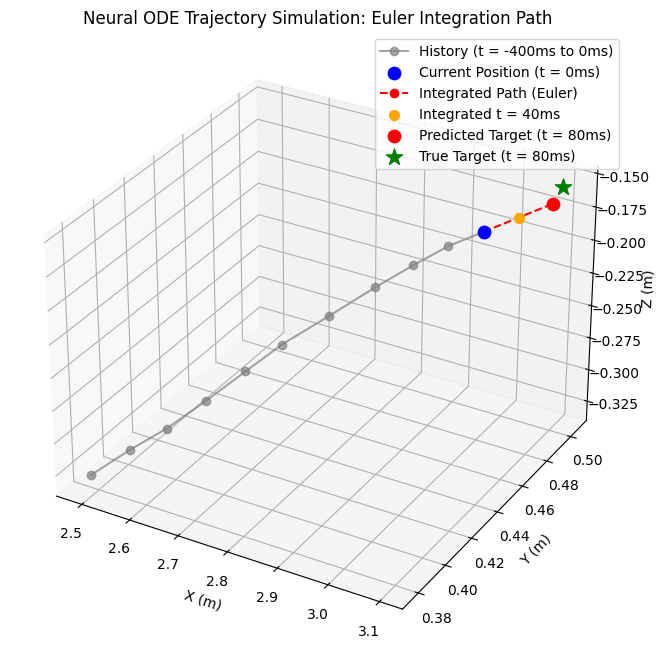

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 검증 데이터셋에서 첫 번째 샘플 선택
sample_idx = 0
X_sample = torch.tensor(Xvl[sample_idx:sample_idx+1], dtype=torch.float32).to(device)
y_sample = torch.tensor(yvl[sample_idx:sample_idx+1], dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    # 24차원 스케일드 피처 추출
    ft, df, plt_, tht, _, _, _, Rt, spt, _, _ = extract_features(X_sample, mean_stats, std_stats)
    latent = model.backbone(ft)
    diffs_local = torch.matmul(df, Rt)
    
    # 적분 초기 상태 (로컬)
    pos_local = torch.zeros((1, 3), device=device)
    vel_local = diffs_local[:, -1] / 0.04
    
    # 단일 스텝 RK4 내부 가상 평가 지점(k1, k2, k3, k4) 추적
    dt = model.dt_physical
    
    dp1, dv1, _ = model._ode_derivative(pos_local, vel_local, latent, tht, spt)
    pos_k2 = pos_local + 0.5 * dt * dp1
    vel_k2 = vel_local + 0.5 * dt * dv1
    
    dp2, dv2, _ = model._ode_derivative(pos_k2, vel_k2, latent, tht, spt)
    pos_k3 = pos_local + 0.5 * dt * dp2
    vel_k3 = vel_local + 0.5 * dt * dv2
    
    dp3, dv3, _ = model._ode_derivative(pos_k3, vel_k3, latent, tht, spt)
    pos_k4 = pos_local + dt * dp3
    vel_k4 = vel_local + dt * dv3
    
    dp4, dv4, _ = model._ode_derivative(pos_k4, vel_k4, latent, tht, spt)
    final_pos_local = pos_local + (dt / 6.0) * (dp1 + 2.0 * dp2 + 2.0 * dp3 + dp4)
    
    # 글로벌 좌표계 변환 헬퍼 함수
    def to_global(local_pos):
        return (plt_ + torch.einsum('nij,nj->ni', Rt, local_pos + model.local_bias) + model.global_bias)[0].cpu().numpy()
        
    p_start = to_global(pos_local)  # t=0ms
    p_k2 = to_global(pos_k2)        # t=40ms
    p_k3 = to_global(pos_k3)        # t=40ms
    p_k4 = to_global(pos_k4)        # t=80ms
    p_final = to_global(final_pos_local)  # 최종 t=80ms

# 과거 궤적 및 정답 정의
history = X_sample[0].cpu().numpy()
true_target = y_sample[0].cpu().numpy()

# 3D 플롯 시각화
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 1. 과거 비행 경로
ax.plot(history[:, 0], history[:, 1], history[:, 2], 'o-', color='gray', label='History (t = -400ms to 0ms)', alpha=0.6)
ax.scatter(history[-1, 0], history[-1, 1], history[-1, 2], color='blue', s=100, label='Current Position (t = 0ms)')

# 2. RK4 중간 샘플링 단계 (연한 빨강선)
rk_path = np.array([p_start, p_k2, p_k3, p_k4])
ax.plot(rk_path[:, 0], rk_path[:, 1], rk_path[:, 2], 'x:', color='orange', label='RK4 Evaluation Steps', alpha=0.8)
ax.scatter(p_k2[0], p_k2[1], p_k2[2], color='orange', marker='x', s=50, label='k2 (t=40ms)')
ax.scatter(p_k3[0], p_k3[1], p_k3[2], color='magenta', marker='x', s=50, label='k3 (t=40ms)')
ax.scatter(p_k4[0], p_k4[1], p_k4[2], color='cyan', marker='x', s=50, label='k4 (t=80ms)')

# 3. RK4 최종 통합 경로
ax.plot([p_start[0], p_final[0]], [p_start[1], p_final[1]], [p_start[2], p_final[2]], '--', color='red', label='Integrated Vector (RK4)')
ax.scatter(p_final[0], p_final[1], p_final[2], color='red', s=100, label='RK4 Final Prediction (t = 80ms)')

# 4. Ground Truth Target
ax.scatter(true_target[0], true_target[1], true_target[2], color='green', marker='*', s=180, label='True Target (t = 80ms)')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Neural ODE (ode_v1) Single-step RK4 Trajectory Simulation')
ax.legend()
plt.show()

## 7. 테스트셋 예측 및 최종 제출
학습된 가벼운 ODE 모델을 이용해 전체 테스트 좌표에 대해 미래 위치를 예측하고, CSV 제출 양식으로 내보냅니다.

In [8]:
model.eval()
N_test = len(X_test)
batch_size_test = 256
preds = np.zeros((N_test, 3), dtype=np.float32)

print("테스트셋 예측 진행 중...")
with torch.no_grad():
    for start in range(0, N_test, batch_size_test):
        end = min(start + batch_size_test, N_test)
        batch = torch.tensor(X_test[start:end], dtype=torch.float32, device=device)
        
        # 테스트 예측 시에도 동일한 훈련 세트 통계량(mean_stats, std_stats)으로 정규화
        ft, df, plt_, tht, _, _, _, Rt, spt, _, _ = extract_features(batch, mean_stats, std_stats)
        pv = model(ft, df, plt_, tht, spt, Rt)
        preds[start:end] = pv.cpu().numpy()

output_csv = "submission_ode_showcase.csv"
sub_df = pd.DataFrame({
    'id': [f"TEST_{i+1:05d}" for i in range(N_test)],
    'x': preds[:, 0],
    'y': preds[:, 1],
    'z': preds[:, 2]
})
sub_df.to_csv(output_csv, index=False)
print(f"✅ 쇼케이스 ODE 예측 제출물 생성 완료: {output_csv}")

테스트셋 예측 진행 중...
✅ 쇼케이스 ODE 예측 제출물 생성 완료: submission_ode_showcase.csv
